## Map Reduce
### Decide no of conditional edges with parallel runs on the go using Send from langgraph.types

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
from langchain_ollama import ChatOllama

load_dotenv("./env")

google_api_key = os.getenv("GOOGLE_API_KEY")
openai_api_key = os.getenv("OPENAI_API_KEY")

google_llm = ChatGoogleGenerativeAI(
    temperature=0, 
    model="gemini-2.5-flash", 
    api_key=google_api_key,
    max_tokens=200
)

openai_llm = ChatOpenAI(
    temperature=0, 
    model="gpt-5-mini", 
    api_key=openai_api_key
)

ollama_llm = ChatOllama(
    model="llama3.1:latest",
    temperature=0
)

# ollama_llm.invoke("what is 2+2").content

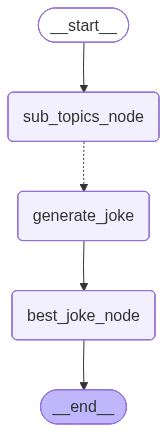

In [2]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from typing import TypedDict, Annotated, Literal
import operator
from langgraph.types import Send
from IPython.display import display, Image
from langchain_core.globals import set_debug

# set_debug(True)


class MainState(TypedDict):
    topic: str
    sub_topic: str
    sub_topics: list[str]
    jokes: Annotated[list[str], operator.add]
    best_joke: str

class StructuredSubTopic(BaseModel):
    sub_topics: list[str]

class StructuredJoke(BaseModel):
    joke: str

class StructuredBestJoke(BaseModel):
    id: int


def sub_topics_node(state: MainState):
    topic = state['topic']
    prompt = f"Generate 3 sub topic name based on this topic {topic}."
    structured_ollama_llm = ollama_llm.with_structured_output(StructuredSubTopic)
    res = structured_ollama_llm.invoke(prompt)
    return {"sub_topics": res.sub_topics}

def generate_joke(state: MainState):
    sub_topic = state['sub_topic']
    prompt = f"Generate a joke on this topic {sub_topic}"
    structured_ollama_llm = ollama_llm.with_structured_output(StructuredJoke)
    res = structured_ollama_llm.invoke(prompt)
    return {"jokes": [res.joke]}


def continue_to_jokes_ce(state: MainState) -> Literal['generate_joke']:
    return [Send("generate_joke", {'sub_topic': s}) for s in state['sub_topics']]


def best_joke_node(state: MainState):
    jokes = state['jokes']
    jokes_combined = "\n\n".join(jokes)
    prompt = f"Select best joke from the list of following jokes and return the id starting with 0 of the following list. {jokes_combined}"
    structured_ollama_llm = ollama_llm.with_structured_output(StructuredBestJoke)
    res = structured_ollama_llm.invoke(prompt)
    return {"best_joke": state['jokes'][res.id]}


builder = StateGraph(MainState)

builder.add_node("sub_topics_node", sub_topics_node)
builder.add_node("generate_joke", generate_joke)
# builder.add_node("continue_to_jokes_node", continue_to_jokes_node)
builder.add_node("best_joke_node", best_joke_node)

builder.add_edge(START, "sub_topics_node")
builder.add_conditional_edges("sub_topics_node", continue_to_jokes_ce, ['generate_joke'])
builder.add_edge("generate_joke", "best_joke_node")
builder.add_edge("best_joke_node", END)


graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))
    


In [3]:
for s in graph.stream({"topic": "Indian Premier League"}):
    print(s)

{'sub_topics_node': {'sub_topics': ['Top Teams in IPL', 'IPL Player Records and Statistics', 'Impact of IPL on Indian Cricket']}}
{'generate_joke': {'jokes': ["Why did the IPL player's statistics go to therapy? Because they were struggling to 'average' out their emotions!"]}}
{'generate_joke': {'jokes': ["Why did the CSK team go to therapy? Because they were struggling with their 'chokers' mentality!"]}}
{'generate_joke': {'jokes': ['Why did the Indian cricket team go to therapy after losing a match? Because they were struggling with the impact of IPL – Inconsistent Performance Leading to Losses!']}}
{'best_joke_node': {'best_joke': "Why did the CSK team go to therapy? Because they were struggling with their 'chokers' mentality!"}}


In [5]:
res = graph.invoke({'topic': 'animals'})

print(res)

{'topic': 'animals', 'sub_topics': ['Wild Animals', 'Domesticated Animals', 'Endangered Species'], 'jokes': ['Why did the cat join a band? Because it wanted to be the purr-cussionist!', 'Why did the cat join a band? Because it wanted to be the purr-cussionist.', 'Why did the endangered species go to therapy? Because it was struggling to adapt!'], 'best_joke': 'Why did the cat join a band? Because it wanted to be the purr-cussionist!'}
